In [3]:
# Importing all the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["figure.figsize"] = (10,5)
sns.set_style("whitegrid")

In [4]:
data=pd.read_csv('/content/UIDAI_Bio_Cleaned_Data.csv')

In [5]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns in the dataset.")

There are 1861108 rows and 9 columns in the dataset.


In [6]:
print(f'Columns in the dataset are: {data.columns.to_list()}')

Columns in the dataset are: ['Date of Updation', 'State', 'Pincode', 'Bio_age_5_17', 'bio_age_17_', 'District', 'Total_Updates', 'Child_Ratio', 'Adult_Ratio']


In [7]:
print("Data types of columns:\n")

data.info()

Data types of columns:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 9 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Date of Updation  object 
 1   State             object 
 2   Pincode           int64  
 3   Bio_age_5_17      int64  
 4   bio_age_17_       int64  
 5   District          object 
 6   Total_Updates     int64  
 7   Child_Ratio       float64
 8   Adult_Ratio       float64
dtypes: float64(2), int64(4), object(3)
memory usage: 127.8+ MB


In [8]:
print('Statistics of numerical columns are:\n')

selected_columns = ['Bio_age_5_17', 'bio_age_17_', 'Total_Updates', 'Child_Ratio', 'Adult_Ratio']
data[selected_columns].describe()

Statistics of numerical columns are:



,Bio_age_5_17,bio_age_17_,Total_Updates,Child_Ratio,Adult_Ratio
count,1.861108e+06,1.861108e+06,1.861108e+06,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01,3.748471e+01,4.728444e-01,5.271492e-01
std,8.370421e+01,8.806502e+01,1.623302e+02,3.038688e-01,3.038694e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00,3.000000e+00,2.500000e-01,3.333000e-01
50%,3.000000e+00,4.000000e+00,8.000000e+00,5.000000e-01,5.000000e-01
75%,1.100000e+01,1.000000e+01,2.200000e+01,6.667000e-01,7.500000e-01
max,8.002000e+03,7.625000e+03,1.338100e+04,1.000000e+00,1.000000e+00


In [9]:
# Checking Null values in the dataset

data.isna().sum()

,0
Date of Updation,0
State,0
Pincode,0
Bio_age_5_17,0
bio_age_17_,0
District,0
Total_Updates,0
Child_Ratio,0
Adult_Ratio,0


In [10]:
# Checking duplicates

print(f'Total duplicate values in the dataset are: {data.duplicated().sum()}')

Total duplicate values in the dataset are: 99498


In [11]:
# Dropping duplicates

data.drop_duplicates(keep='first',inplace=True)

In [12]:
data.shape

(1761610, 9)

In [13]:
data.duplicated().sum()

np.int64(0)

### Feature Engineering

In [14]:
# Converting 'Date of Updation' column to datetype

data["Date of Updation"] = pd.to_datetime(data["Date of Updation"], dayfirst=True)

In [15]:
# Adding seperate columns for year, month and month_year

data["Year"] = data["Date of Updation"].dt.year
data["Month"] = data["Date of Updation"].dt.month
data["Month_Year"] = data["Date of Updation"].dt.to_period("M")

In [16]:
data.head()

,Date of Updation,State,Pincode,Bio_age_5_17,bio_age_17_,District,Total_Updates,Child_Ratio,Adult_Ratio,Year,Month,Month_Year
0,2025-11-17,Jammu and Kashmir,181206,0,1,Unknown,1,0.0,1.0,2025,11,2025-11
1,2025-12-14,Telangana,504310,1,0,Adilabad,1,1.0,0.0,2025,12,2025-12
2,2025-12-14,Telangana,504309,3,2,Adilabad,5,0.6,0.4,2025,12,2025-12
3,2025-12-14,Telangana,504299,1,0,Adilabad,1,1.0,0.0,2025,12,2025-12
4,2025-12-14,Telangana,504295,0,1,Adilabad,1,0.0,1.0,2025,12,2025-12


### Exploratory Data Analysis (EDA)

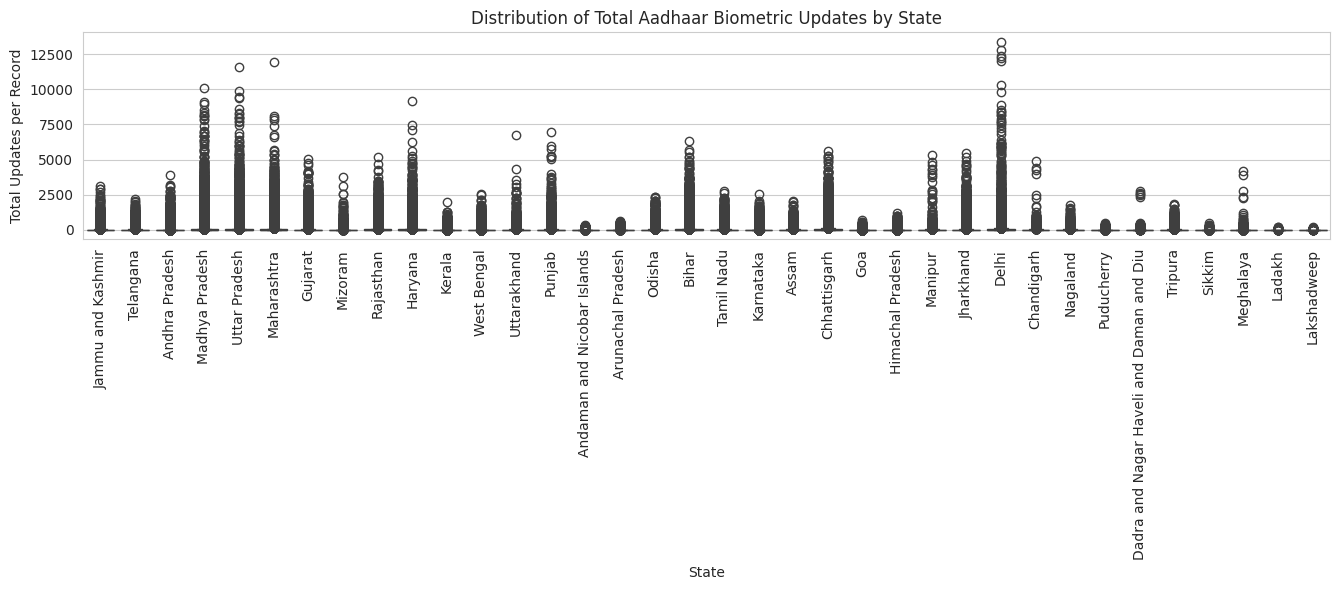

In [17]:
# distribution of 'Total_Updates' by 'State'

plt.figure(figsize=(13.5,6))
sns.boxplot(x='State', y='Total_Updates', data=data)
plt.title('Distribution of Total Aadhaar Biometric Updates by State')
plt.xlabel('State')
plt.ylabel('Total Updates per Record')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insights from above graph:**

This box plot reveals that biometric update activity is heavily concentrated in high-population states like Uttar Pradesh, Maharashtra, and Madhya Pradesh, which exhibit the most significant "vertical spread" and extreme outliers reaching up to 12,000 updates per record. The data shows a strong positive skew, where the vast majority of records cluster near the baseline while a small number of "power users" or specific regional centers drive massive update volumes. In contrast, smaller states and union territories like Lakshadweep and Ladakh show nearly flat distributions, indicating either high system saturation or potential gaps in accessibility.

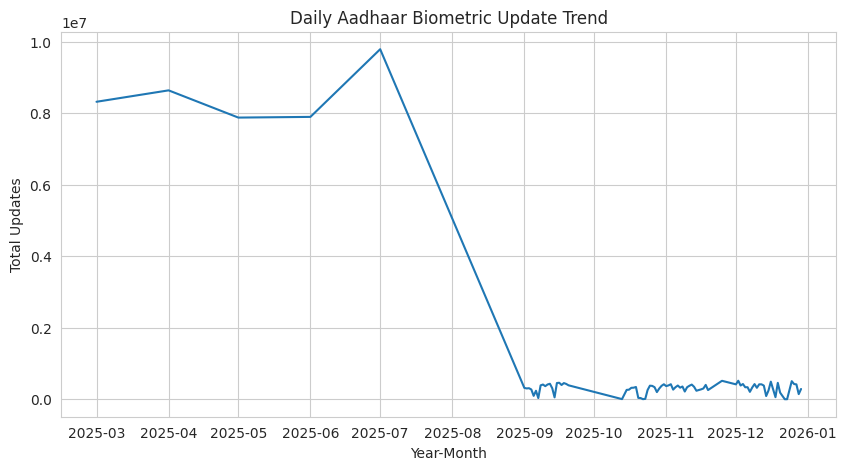

In [18]:
# Daily Aadhaar Biometric Update Trend

daily_updates = data.groupby("Date of Updation")["Total_Updates"].sum()
plt.plot(daily_updates.index, daily_updates.values)
plt.title("Daily Aadhaar Biometric Update Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Updates")
plt.show()

**Insights from above graph:**

The presence of sharp temporal peaks suggests policy-driven or campaign-driven enrolment waves, rather than uniform daily demand.

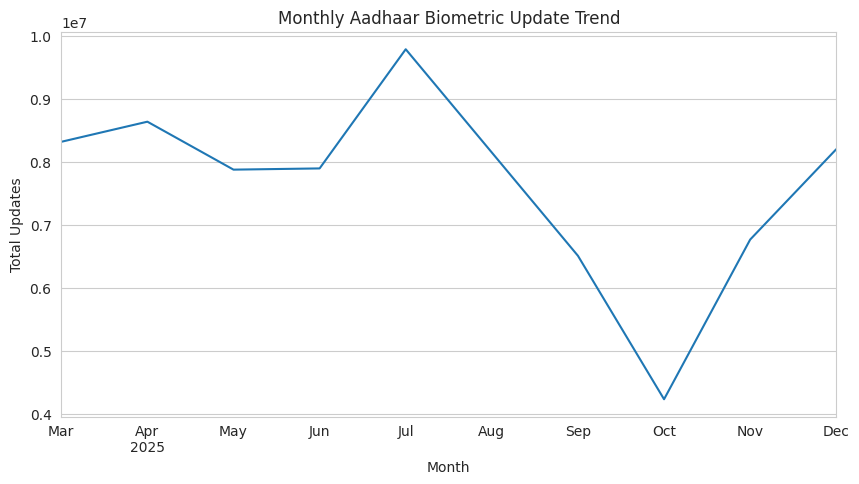

In [19]:
monthly = data.groupby("Month_Year")["Total_Updates"].sum()

monthly.plot()
plt.title("Monthly Aadhaar Biometric Update Trend")
plt.xlabel("Month")
plt.ylabel("Total Updates")
plt.show()

**Insights from above graph:**

Above graph reveals a highly volatile service demand throughout 2025, peaking dramatically in July at approximately 6 million updates before plunging to a yearly low of 2.5 million in October. This sharp 58% decline followed by a rapid recovery to nearly 5 million updates by December highlights a significant challenge in operational consistency.

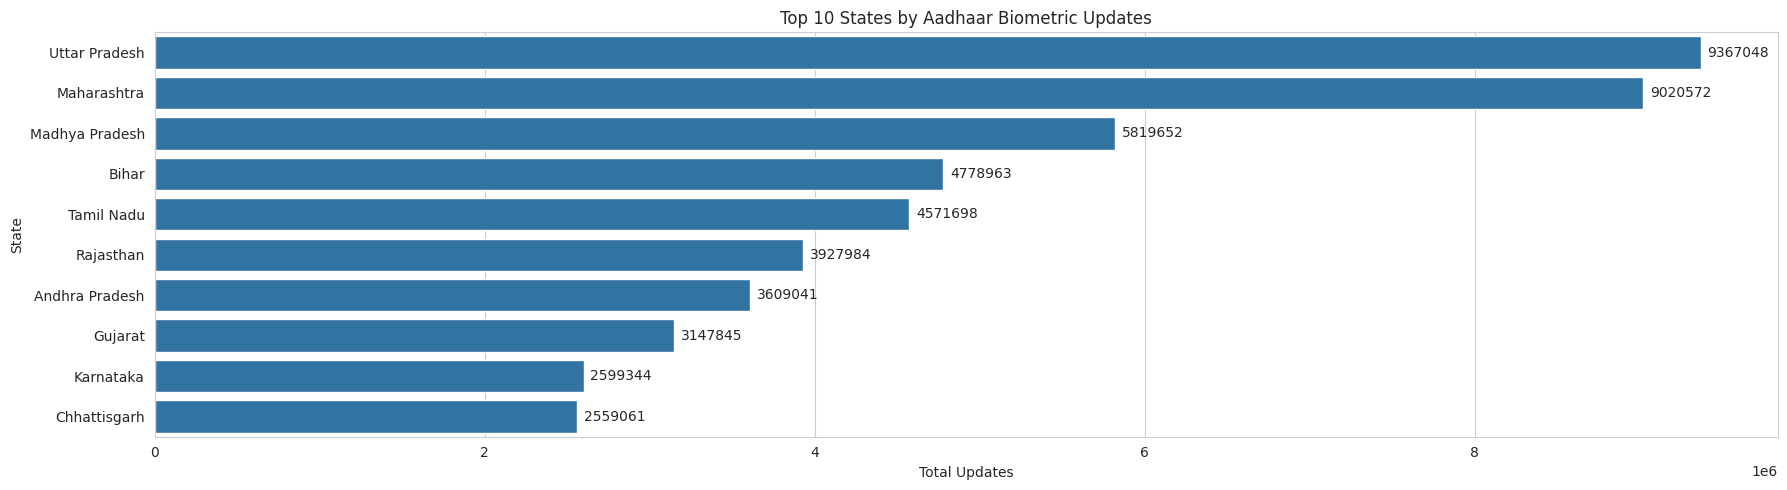

In [20]:
state_updates = (data.groupby("State")["Total_Updates"]
    .sum()
    .sort_values(ascending=False))

plt.figure(figsize=(18,5))
ax = sns.barplot(x=state_updates.head(10).values,y=state_updates.head(10).index)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.title("Top 10 States by Aadhaar Biometric Updates")
plt.xlabel("Total Updates")
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Insights from above graph:**

High-update states align strongly with population density and service accessibility, highlighting uneven digital identity participation across India. Aadhaar biometric updates are highly concentrated in a few states, indicating unequal administrative load and population-driven demand.

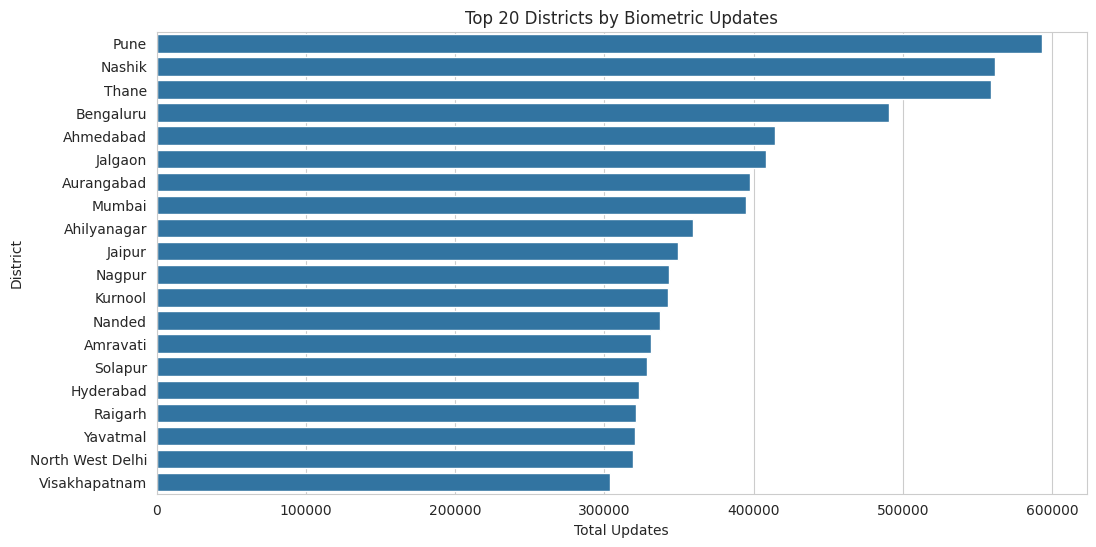

In [21]:
district_updates1 = (
    data.groupby('District')['Total_Updates']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=district_updates1.values,
    y=district_updates1.index
)
plt.title("Top 20 Districts by Biometric Updates")
plt.xlabel("Total Updates")
plt.ylabel("District")
plt.show()


**Insights from above graph:**

The data reveals a stark divide in biometric activity, where urban hubs like Bengaluru and Ahmedabad dominate update volumes, reaching nearly 500,000 requests per district. Furthermore, the significant outliers in states like Uttar Pradesh and Maharashtra with some records hitting 12,000 updates—contrast sharply with the near-zero activity in remote regions like Lakshadweep, highlighting a critical need for targeted infrastructure and seasonal resource balancing.

District
Adilabad        127445
Agarmalwa        16361
Agra            229464
Ahilyanagar     359172
Ahmedabad       414421
                 ...  
Yadgir           64269
Yamuna Nagar     87534
Yanam              202
Yavatmal        320220
Zunheboto         7760
Name: Total_Updates, Length: 805, dtype: int64


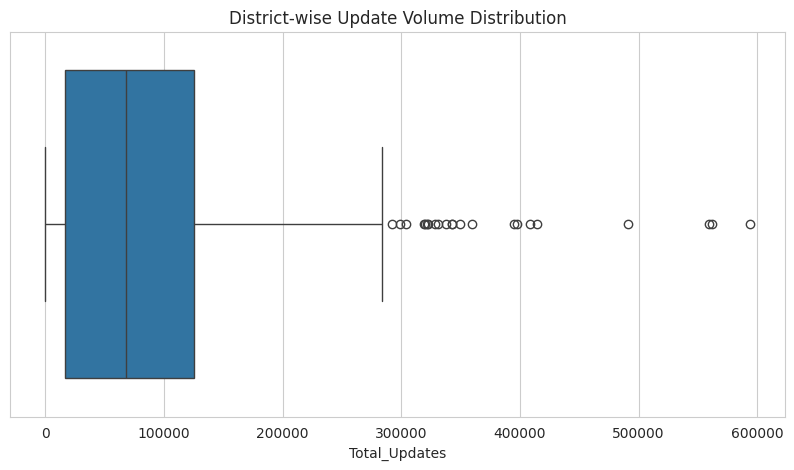

In [22]:
district_updates2 = data.groupby("District")["Total_Updates"].sum()
print(district_updates2)
sns.boxplot(x=district_updates2)
plt.title("District-wise Update Volume Distribution")
plt.show()

**Insights from above graph:**

Extreme outliers indicate district-level infrastructure imbalance, where few districts handle disproportionate Aadhaar update loads.

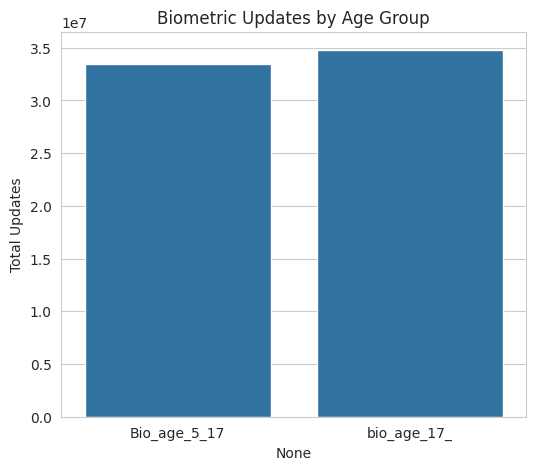

In [23]:
age_totals = data[['Bio_age_5_17', 'bio_age_17_']].sum()

plt.figure(figsize=(6,5))
sns.barplot(
    x=age_totals.index,
    y=age_totals.values
)
plt.title("Biometric Updates by Age Group")
plt.ylabel("Total Updates")
plt.show()


**Insights from above graph:**

The bio_age_17_ (representing individuals over 17) shows a slightly higher number of updates compared to the Bio_age_5_17 group. The distribution between these two segments is nearly equal, suggesting that biometric maintenance is consistently active across both minors and adults.

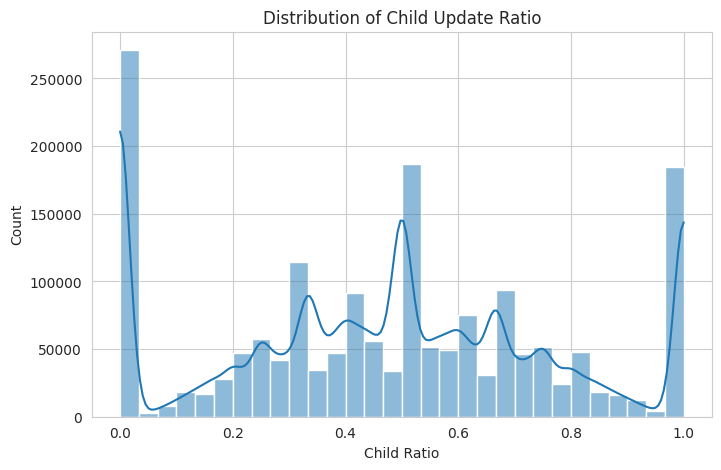

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data['Child_Ratio'], bins=30, kde=True)
plt.title("Distribution of Child Update Ratio")
plt.xlabel("Child Ratio")
plt.show()


**Insights from above graph:**

Wide variance in child ratios indicates uneven compliance and awareness across regions

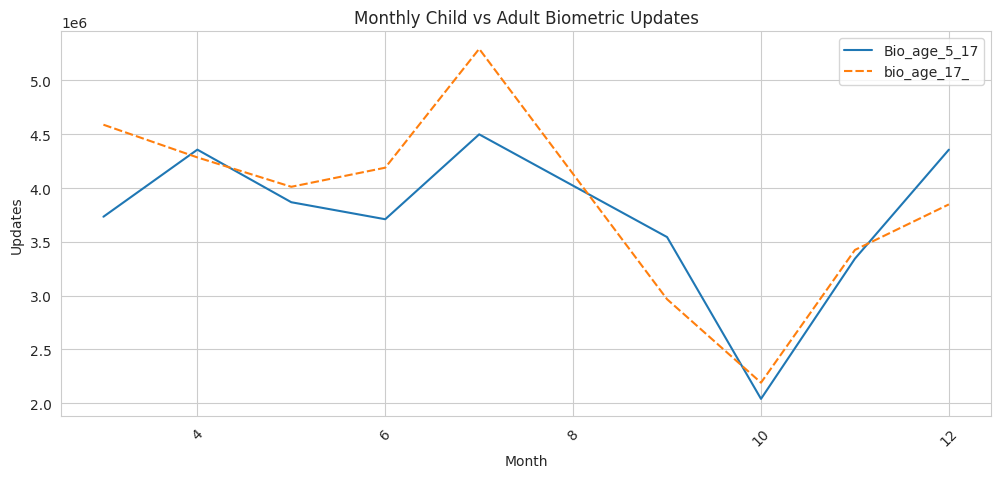

In [25]:
# Child vs Adult Trend Over Time

monthly_age = data.groupby('Month')[['Bio_age_5_17', 'bio_age_17_']].sum()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_age)
plt.title("Monthly Child vs Adult Biometric Updates")
plt.xlabel("Month")
plt.ylabel("Updates")
plt.xticks(rotation=45)
plt.show()


**Insights from above graph:**

The graph reveals a highly correlated trend between child (5–17) and adult (17+) biometric updates, characterized by shared seasonal volatility:

 - Peak & Trough: Both groups reached a maximum in Month 7 (July) and experienced a sharp, simultaneous crash in Month 10 (October).

 - Demographic Shift: Adults generally led in update volume during the first half of the year, while the 5–17 age group showed a much stronger recovery and dominance in the final quarter.

 - Year-End Surge: After the October low, both demographics saw a massive spike, with children’s updates nearly doubling by Month 12 to finish the year as the more active group.

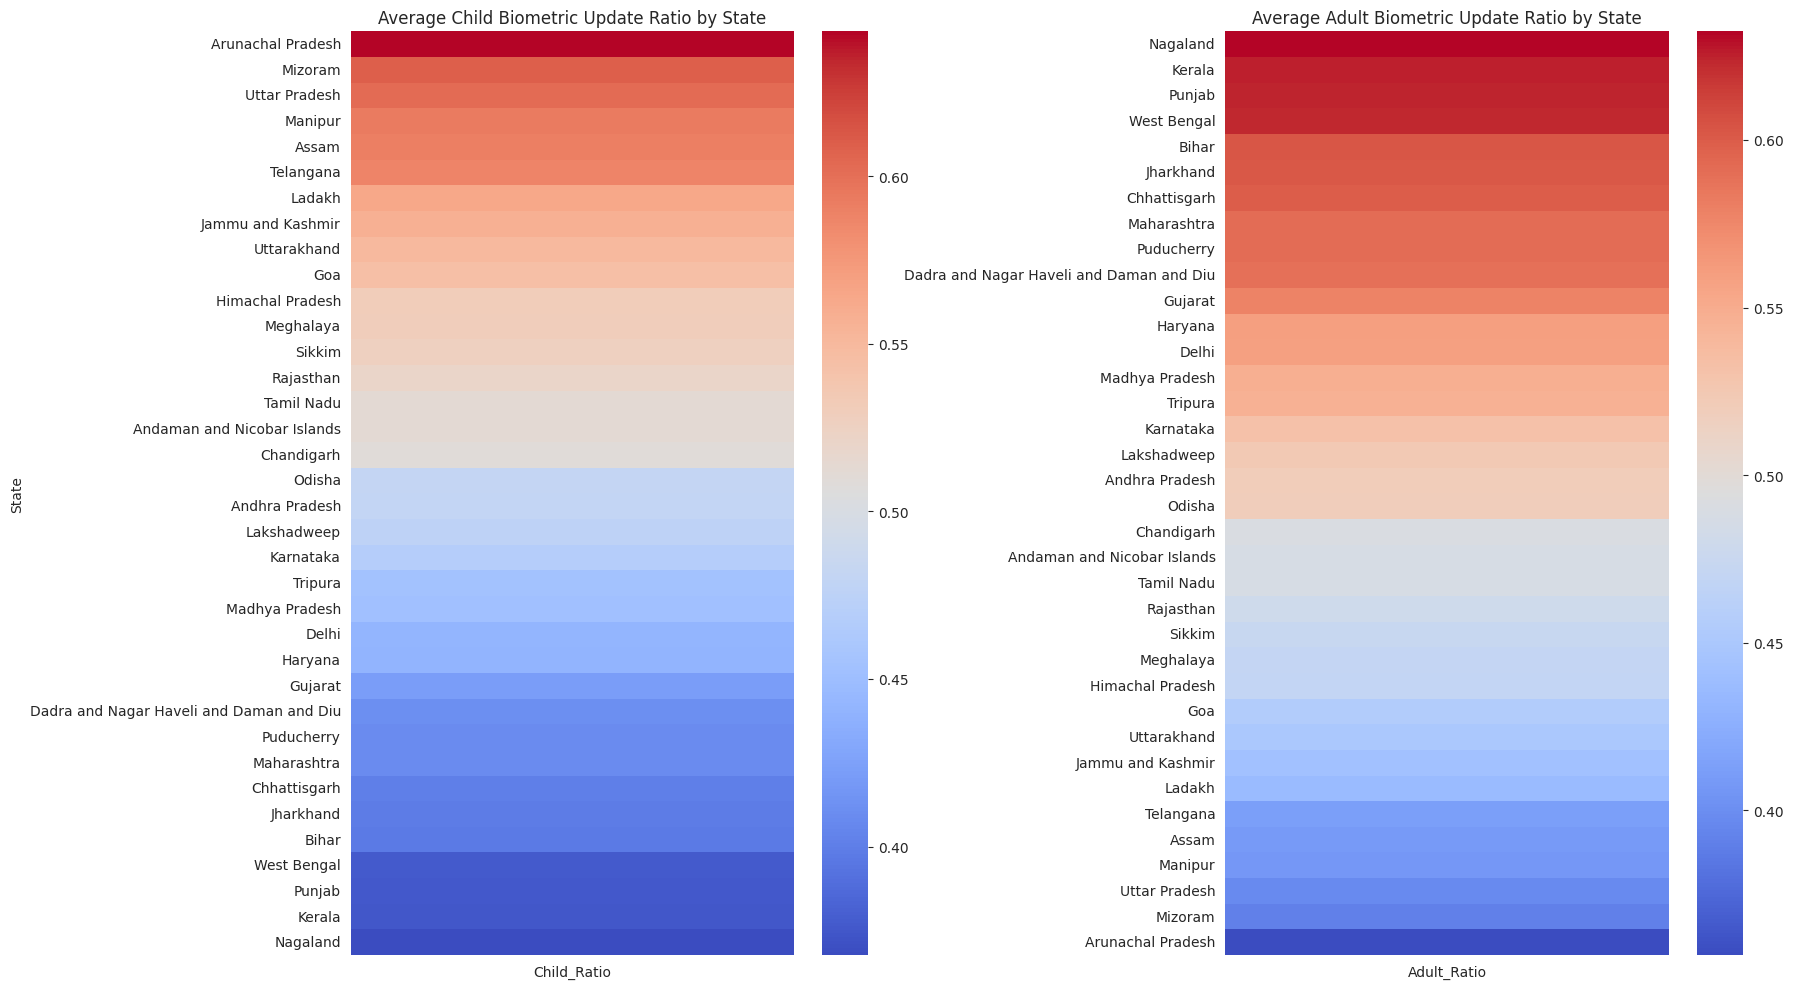

In [26]:
# Child Ratio heatmap
child_ratio_pivot = data.pivot_table(
    values="Child_Ratio",
    index="State",
    aggfunc="mean"
).sort_values(by="Child_Ratio", ascending=False)

# Adult Ratio heatmap
adult_ratio_pivot = data.pivot_table(
    values="Adult_Ratio",
    index="State",
    aggfunc="mean"
).sort_values(by="Adult_Ratio", ascending=False)

# figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plotting Child Ratio heatmap
sns.heatmap(child_ratio_pivot, cmap="coolwarm", ax=axes[0])
axes[0].set_title("Average Child Biometric Update Ratio by State")
axes[0].set_ylabel("State")

# Plotting Adult Ratio heatmap
sns.heatmap(adult_ratio_pivot, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Average Adult Biometric Update Ratio by State")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Insights from above graph:**

Analyzing the two heatmaps for child and adult biometric update ratios by state reveals some interesting patterns:

There appears to be an inverse relationship in some states: where child ratios are high, adult ratios tend to be lower, and vice versa. This could point to varying demographic structures, targeted policy implementations, or differing levels of awareness and accessibility for specific age groups across states.
The disparities highlight the need for tailored strategies for biometric updates, focusing on the specific age demographic that is underserved in each state.

## Daily Anomalies

We have calculated the mean and standard deviation of 'Total_Updates' on a daily basis. Then, we identified data points that fall outside a certain number of standard deviations from the mean (e.g., 2 or 3 standard deviations) to flag as anomalies.


In [27]:
daily_mean = daily_updates.mean()
daily_std = daily_updates.std()

upper_bound = daily_mean + (3 * daily_std)
lower_bound = daily_mean - (3 * daily_std)

anomalies = daily_updates[(daily_updates > upper_bound) | (daily_updates < lower_bound)]

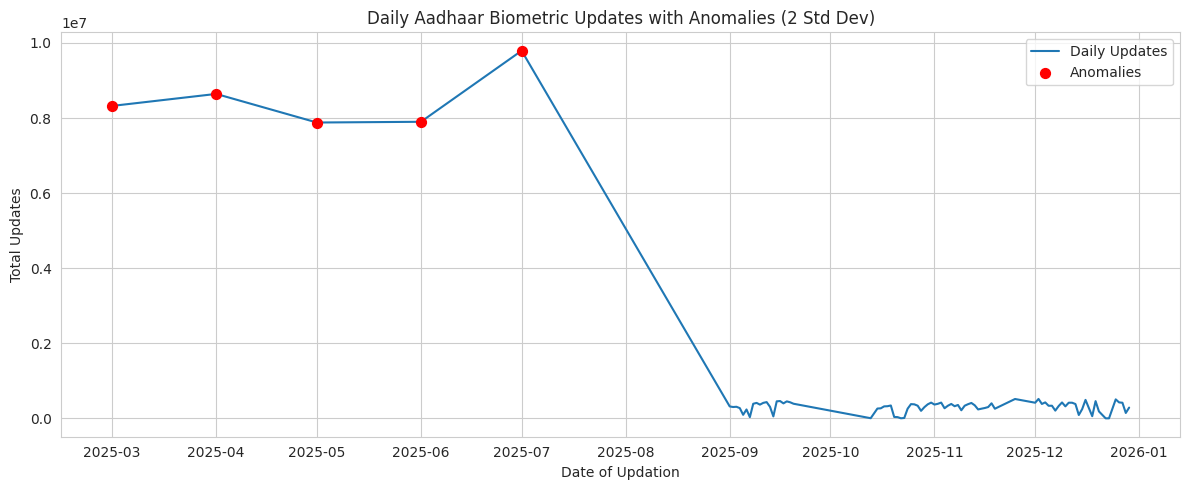

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(daily_updates.index, daily_updates.values, label='Daily Updates')
plt.scatter(anomalies.index, anomalies.values, color='red', label='Anomalies', s=50, zorder=5)
plt.title('Daily Aadhaar Biometric Updates with Anomalies (2 Std Dev)')
plt.xlabel('Date of Updation')
plt.ylabel('Total Updates')
plt.legend()
plt.tight_layout()
plt.show()

### Summary of Anomalies

The anomaly detection analysis, using a threshold of 2 standard deviations from the daily mean of 'Total_Updates', revealed several significant peaks in Aadhaar biometric updates. These anomalies consistently occurred at the beginning of months (specifically March, April, May, June, and July 2025).

**Insights Gained:**

*   **Policy-driven or Campaign-driven Enrolment Waves:** The clustering of anomalies at the start of months suggests that these high-volume update days are likely not due to organic, uniform daily demand but rather indicate specific, scheduled events. This could be due to government campaigns, policy deadlines, or targeted enrolment drives that commence at the beginning of a new month.
*   **Resource Allocation Impact:** Such sharp, predictable spikes can have significant implications for resource allocation, staffing, and infrastructure planning at Aadhaar update centers. Understanding these patterns can help UIDAI and its partners better prepare for these high-demand periods.
*   **Data Integrity and Reporting:** While flagged as statistical anomalies, these points might not indicate data errors but rather unusual, yet explainable, operational events. Further investigation into the specific dates of these anomalies could correlate them with official announcements or program rollouts.

In conclusion, the anomalies identified provide valuable insights into the operational dynamics of Aadhaar biometric updates, pointing towards periodic, high-impact events rather than irregularities in data collection.

#### Predictive Modeling

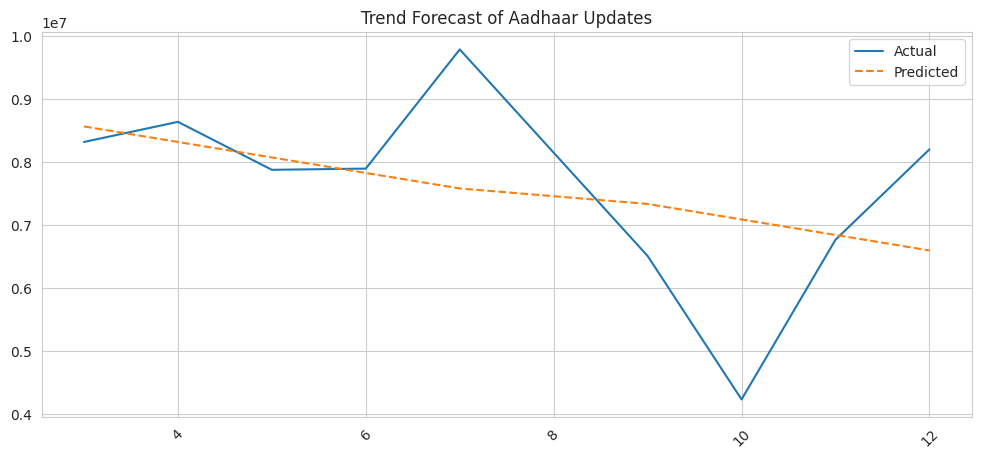

In [29]:
from sklearn.linear_model import LinearRegression

monthly_updates = (
    data.groupby('Month')['Total_Updates']
    .sum()
)
monthly_df = monthly_updates.reset_index()
monthly_df['t'] = np.arange(len(monthly_df))
X = monthly_df[['t']]
y = monthly_df['Total_Updates']
model = LinearRegression()
model.fit(X, y)
monthly_df['prediction'] = model.predict(X)

plt.figure(figsize=(12,5))
plt.plot(monthly_df['Month'], y, label='Actual')
plt.plot(monthly_df['Month'], monthly_df['prediction'], linestyle='--', label='Predicted')
plt.xticks(rotation=45)
plt.title("Trend Forecast of Aadhaar Updates")
plt.legend()
plt.show()